In [8]:
import zipfile
import os

In [9]:
zip_path = "archive.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['dataset.csv']


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

df = pd.read_csv("data/dataset.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Vilka är de mest populära låtarna ?

Nedan kommer jag sortera låtar eftar popularitet och visa topp 10 

In [12]:
df = df.drop_duplicates(subset=["track_name", "artists"])

df[['track_name', 'artists', 'popularity']].sort_values(by='popularity',
 ascending=False
).head(10)

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
67359,Tití Me Preguntó,Bad Bunny,97
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
20000,Under The Influence,Chris Brown,96
67559,Efecto,Bad Bunny,96
79000,I Ain't Worried,OneRepublic,96
67500,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95


# Genre vs Popularity
I denna analys undersöker jag vilka musikgenrer som har högst genomsnittlig popularitet på spotify 

Genom att gruppera låtar efter genre och beräkna medelvälrde av popularitet kan vi se vilka musiktitlar som genrellet lyssnas mest på. 

Detta ger en bättre bild än att bara tittat på enskilda låtar, eftersom det visar övergripande trender i lyssningsbeteende. 

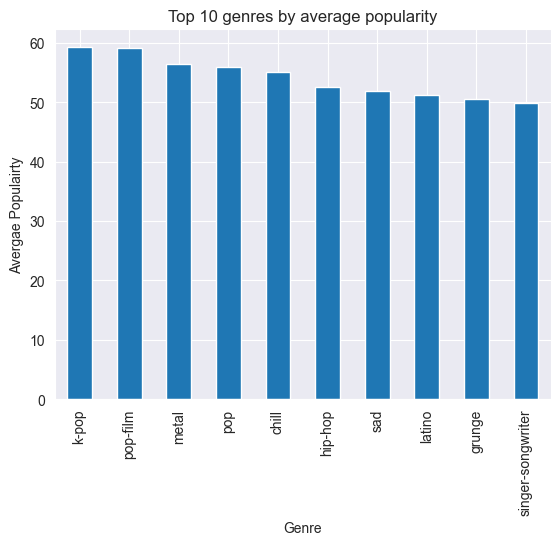

In [27]:
genre_popularity = df.groupby("track_genre")["popularity"].mean()

genre_popularity = genre_popularity.sort_values(ascending=False)

genre_popularity.head(10)

top_genres = genre_popularity.head(10)

top_genres.plot(kind="bar")

plt.title("Top 10 genres by average popularity")
plt.xlabel("Genre")
plt.ylabel("Avergae Populairty")

plt.show()

## Genre Analysis: Popularity, Energy & Danceability

I denna analys undersöker jag de 10 mest populära musikgenrerna baserat på genomsnittlig popularitet.

För varje genre jämförs även två viktiga musikaliska egenskaper:
- **Energy**: hur intensiv och energisk musiken är
- **Danceability**: hur lätt låten är att dansa till

Genrerna har sorterats efter popularitet, men själva visualiseringen fokuserar på energy och danceability för att tydligare kunna jämföra musikaliska skillnader mellan genrer utan att popularitetsskalan påverkar diagrammet.

Detta gör det möjligt att se hur olika genrer skiljer sig åt i stil och känsla, inte bara i hur mycket de lyssnas på.

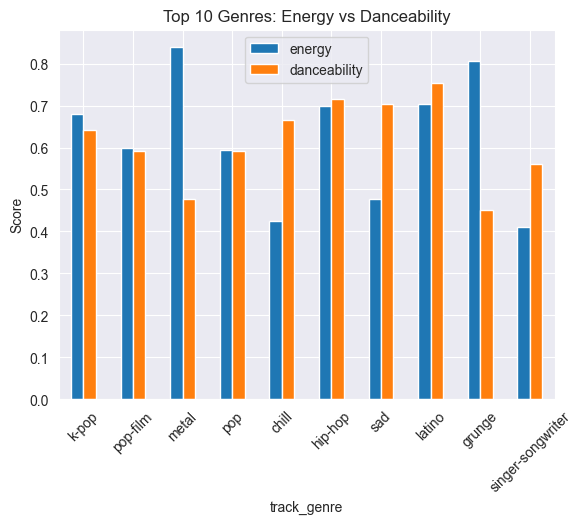

In [26]:
genre_stats = df.groupby("track_genre")[["popularity","energy", "danceability"]].mean()

top_genres = genre_stats.sort_values(by="popularity", ascending=False).head(10)
    
top_genres[["energy", "danceability"]].plot(kind="bar")

plt.title("Top 10 Genres: Energy vs Danceability")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Heatmap: Correlation Between Music Features

I denna analys undersöks hur olika musikaliska egenskaper i Spotify-datasetet hänger ihop.

Genom att beräkna korrelationen mellan variabler som energy, danceability, tempo och popularity kan vi identifiera mönster i vad som kännetecknar olika typer av musik.

Detta hjälper oss att förstå vilka egenskaper som tenderar att förekomma tillsammans, samt vilka som har motsatt samband.

Heatmapen visar dessa samband visuellt där starkare färger representerar starkare relationer mellan variablerna.

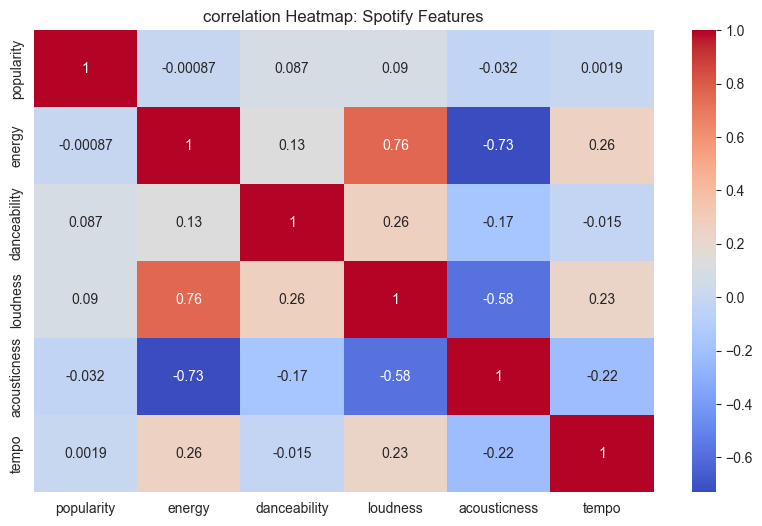

In [25]:
features = df[["popularity", "energy", "danceability", "loudness", "acousticness", "tempo"]]

corr = features.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("correlation Heatmap: Spotify Features")
plt.show()

Sammanfattningsvis visar heatmapen att vissa musikaliska egenskaper, såsom energy och loudness, har starka samband, medan andra variabler som tempo och popularity är mer oberoende.

Detta indikerar att vissa delar av musiken är starkt kopplade till hur låten upplevs, medan andra faktorer påverkas av fler variabler.

# Vad kännetecknar en hit-låt?

I denna analys undersöker jag vad som kännetecknar en “hit-låt” i Spotify-datasetet.

En låt definieras som en hit om den ligger bland de 25% mest populära låtarna i datasetet.

Genom att jämföra dessa låtar med resten av datasetet kan vi identifiera skillnader i musikaliska egenskaper såsom energy, danceability, tempo och loudness.

Syftet är att hitta mönster som kan ge en indikation på vilka faktorer som ofta förekommer i populära låtar, även om det inte nödvändigtvis innebär orsakssamband.


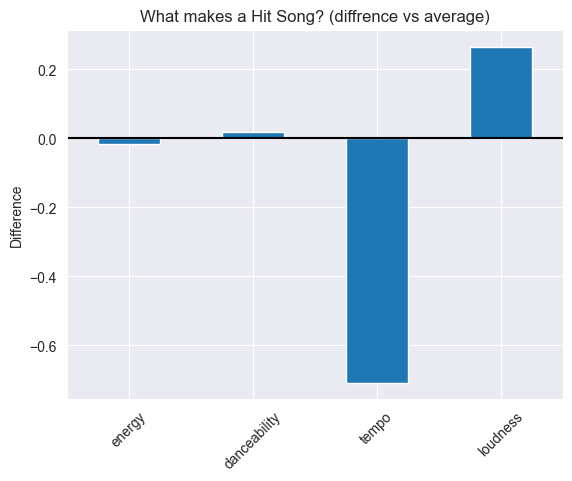

In [28]:
threshold = df["popularity"].quantile(0.75)

# skapar en dataframe med bara hits
hits = df[df["popularity"] >= threshold]

# Beräknar medelvärde på core features
features = ["energy", "danceability", "tempo", "loudness"]

# medelvärde av features för hits
hits_mean = hits[features].mean()

# medelvärde av features för alla låtar 
all_mean = df[features].mean()

comparison = hits_mean - all_mean
comparison 

comparison.plot(kind="bar")

plt.title("What makes a Hit Song? (diffrence vs average)")
plt.ylabel("Difference")
plt.xticks(rotation=45)
plt.axhline(0, color="black")
plt.show()

Analysen visar att hit-låtar i datasetet tenderar att vara mer högljudda och något mer dansbara än genomsnittet.

Samtidigt har de något lägre tempo och något lägre energy än genomsnittet, vilket antyder att populära låtar inte nödvändigtvis är de mest intensiva eller snabba.

Detta tyder på att popularitet inte enbart drivs av energi, utan snarare av en kombination av ljudstyrka och rytmiska egenskaper.